# D1 to D4 - Jony Ling

## D1 - Data and catalog: a home-grown 25-class Singapore dataset

What: Replaced the course-default GroceryStoreDataset with `sg_data/` — 25 SG grocery classes, 998 scraped FairPrice studio images, real median SGD prices, a DINOv2 gallery index, and 17 manually verified real in-store/home photos. Every image has a provenance row (source URL, license, scrape date) in `*_raw.csv`, and every notebook gained a `USE_SG_CATALOG` toggle so the course-default path still runs.

Why: A Singapore self-checkout should recognize Milo, kailan and Pasar eggs with SGD prices — and a dataset you built yourself is one you can actually trust and debug.

Result: Manual inspection caught a mangosteen labelled as mango, a scanned 1902 agricultural bulletin labelled "bananas", restaurant dishes labelled "banana leaf", HTML error pages saved as .jpg, and stock photos posing as store photos — none of which a filename-based pipeline would have caught.

## D2 - Detection: composed scenes, then basket hardening

What: Fine-tuned class-agnostic YOLO11n on composed scenes (mAP50-95 0.76). When a real 5-product NTUC basket photo produced ZERO detections, added a second "hardened" training set — GrabCut product cutouts, 3-8 per scene with real occlusion and rotation on store/floor/basket backgrounds — and retrained.

Why: The original scenes were square packshots on near-white canvases; the domain gap that broke recognition (see D4) breaks detection the same way.

Result: Basket photo 0 -> 7 confident boxes; end-to-end top-1 on the 17 real photos improved 11/17 -> 13/17. A "better-labeled" variant scored higher val mAP (0.805 vs 0.735) but over-segmented real photos — evaluation on synthetic data ranked the models backwards, so it was measured and rejected.

## D3 - Recognition: frozen DINOv2 + linear head, and honest calibration

What: 25-way linear head on frozen DINOv2 (94% validation, crop-aware). Split detector crops 70/30 into `crops_train.csv` / `calibration_crops.csv` after discovering the confidence threshold was being calibrated on crops the head had trained on.

Why: The leak made every threshold look perfect (sweep collapsed to a meaningless 0.05) and let wrong predictions through the live demo unflagged.

Result: Leakage-free threshold 0.6 at a 98% target; the earlier degenerate calibration became a documented lesson rather than a shipped bug.

## D4 - Augmentation: the decisive experiment (the headline result)

What: Built the copy-paste composite pipeline (GrabCut cutouts, feathered alpha blend + drop shadow + brightness matching onto real SG store scenes; 200 composites with full provenance), then a seeded, budget-matched experiment using the 17 real photos as a held-out test set, 5 seeds, mean +/- std.

Why: An accidental control (two heads trained on identical data differing by 0.05) exposed an unseeded noise floor — so any honest lift claim needed seeds, matched budgets, and a test set with headroom.

Result: Baseline 50.6% +/- 10.3 -> copy-paste 80.0% +/- 2.9 (**+29.4 points, ~10x the seed noise**); classical flip/rotate/jitter +0. Negative result: extending composites to all 25 classes on the same 4 backgrounds COLLAPSED real accuracy to 39% (background shortcut) — measured, diagnosed, and guarded in code.

## Serving & integration (cross-cutting)

What: ONNX export (parity 1.4e-6) + int8 quantization (10.6 KB head); the artifact-bundle contract (`~/SmartCart_bundle`) all five days read/write; integration of Hongming's and Huimin's work into that contract (details in their sections below); Basket mode in the final app (FastSAM proposals x gallery open-set gate — junk scores <=0.07 cosine vs >=0.27 for real products — with per-slot Include ticks and automatic handoff on the clutter signature); 9% GST + plastic-bag question on the receipt; the Week4_Capstone package itself (README, KEY_LEARNINGS.md, requirements.txt, LICENSE, docs/DEVELOPMENT_CHAT_LOG.md).

Result: A shopper-ready demo — head_v2 at 76.5% on real photos / 96.2% on held-out crops, receipts in SGD with GST, and every checkout correction feeding the retraining loop.

# D5 - Hongming Xu
## Enhancement done for Explainability

#1. Batched, reusable occlusion sensitivity

What: Replaced the original single-image, hardcoded occlusion heatmap with `explain_prediction()` — runs all 49 grid cells through the backbone in batches instead of one forward pass per cell, and works on any image path.

Why: The original version was slow (49 individual forward passes) and could only ever explain one fixed validation example, which isn't usable for a live app or for systematic diagnosis.

Result: ~25x fewer backbone calls per explanation, and the same function now powers both the notebook diagnostics and the eventual Day 5 live-upload path.


#2. Nearest-catalog-image lookup

What: Added `EmbeddingIndex` (loaded from Day 1's saved gallery) and `find_similar_products()`, wired into `explain_prediction()` and `plot_explanation()` so each explanation now shows the top-k visually similar catalog products alongside the heatmap.

Why: to have explainability goal of "similar catalog images and Grad-CAM evidence"

Result: Every explanation panel now answers two different questions side by side: "which pixels mattered" (heatmap) and "what does the model think this looks like" (nearest neighbors).

Screenshot for 1 and 2

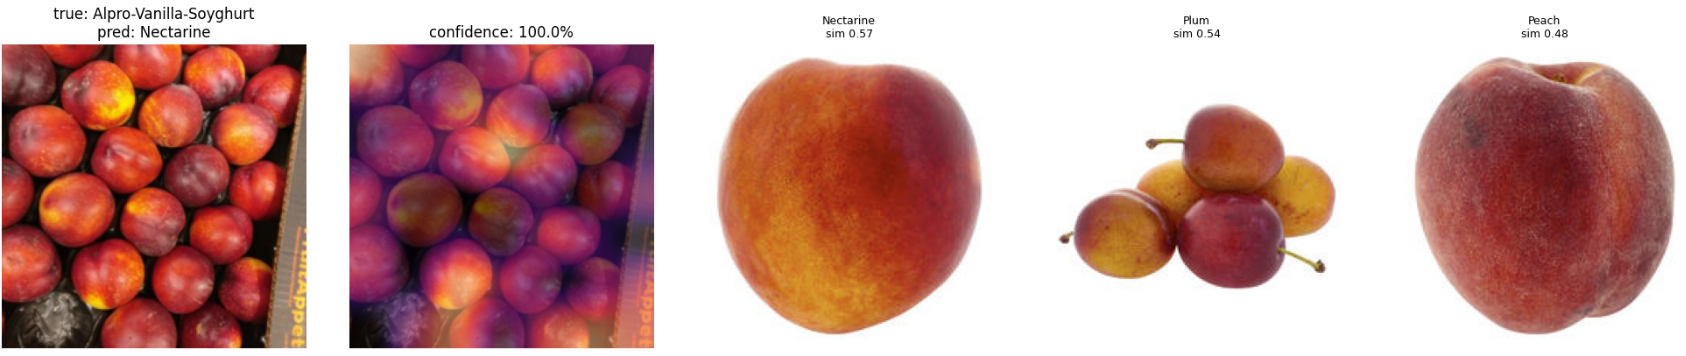

#3. Grad-CAM after recognition classifier fine tuning

What: Added `YOLOBoxScoreTarget` and `yolo_gradcam()`, running Grad-CAM against `detector.model`'s last conv block.

Why: additional confidence applied after recongition / detection stage

Result: Detection-stage explainability ("why did it box something here") now exists as a separate, complementary view to Day 3's recognition-stage explainability ("why did it call this a Granny Smith apple").

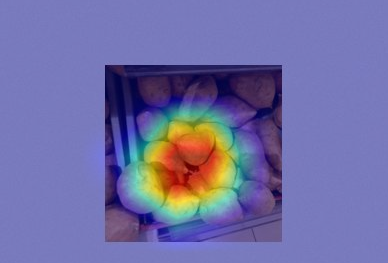

#4. Background-shortcut diagnostic

What: Added a loop checking `explain_prediction()` across 5 examples each of a misread's true class and predicted class.

Why: A misclassification with a high confidence with the heatmap on the background, not the product, suggested possible shortcut learning rather than genuine uncertainty.

Result: Direct evidence of whether the background attention is class-specific and systematic, or an isolated case — informs whether retraining is actually justified.

#5. Crop-aware retraining experiment

What: Added a second head (`head_crop_aware`) trained on Day 1's clean photos combined with Day 2's real detector crops, plus a before/after comparison of the occlusion explanation on the same problem image.

Why: The original head only ever saw clean, well-framed catalog photos — never the tighter, sometimes-imperfect crops it will actually receive at inference from Day 2's detector.

Result: Direct accuracy and heatmap-behavior comparison between clean-only and crop-aware training, to test whether exposure to real crop framing reduces reliance on background cues.

#6. Crop-aware training preserved

What: Modified the retraining cell to load Day 2's crops_manifest.csv and merge it into base_pool before computing features, instead of rebuilding head_before from clean photos alone.

Why: Day 4 was retraining entirely from scratch using list_images(root) — the same clean-only images that caused the fridge-background shortcut in Day 3. Since Day 5 always prefers head_v2.pt over head.pt, this meant Day 3's crop-aware fix would get silently discarded the moment Day 4 ran, regardless of how well it worked.

Result: head_before and head_v2 now both build on the same crop-aware foundation Day 3 established, so the improvement actually survives into the shipped model instead of being reset.


## As integrated into this capstone (what shipped where)

Hongming's six enhancements above were written against his standalone notebooks (Colab paths, the 81-class course dataset, USD). The ideas were ported into the shared SG-bundle pipeline with him credited in each cell — originals preserved under `reference/hongming_originals/`:

- **Shipped as-is (adapted to the SG contract):** batched occlusion `explain_prediction()`/`plot_explanation()` and the background-shortcut diagnostic loop (Day 3); `YOLOBoxScoreTarget` + `yolo_gradcam()` (Day 2 — port required an Ultralytics autograd fix: `detect_head.dynamic = True` for inference-mode-poisoned anchor tensors); crop-aware retraining (Day 3/4 — adopted as the SHIPPED head after a 5-seed head-to-head showed it equal-or-better everywhere: real 34.1% vs 31.8%, crops 91.5% vs 89.2%).
- **Design kept, implementation redone:** his confidence-gate / `needs_review` concept powers the final app's flagging, rewritten as `score_onnx_logits()` because serving runs on ONNX Runtime, and calibrated on the leakage-free crop split.
- **Grew beyond the original:** the nearest-catalog-image lookup (`EmbeddingIndex`) now ALSO serves as the Basket-mode open-set junk rejector — his "show similar catalog images" idea became the thing that stops basket-rim fragments being billed as Yeos tea.
- **Superseded:** his Day 5b demo notebook was replaced by the v2 final app (kept in `reference/` for provenance).

# Final app - Goh Hui Min | Editable Receipt Self-Improvement Loop
Extended the checkout demo so shoppers can correct a misrecognized item or price before confirming, and those corrections get saved automatically instead of being lost. Re-running Day 3's retrain step folds these corrections back into the classifier — including handling genuinely new products it's never seen before — and Day 5a automatically deploys whichever improved model is newest, all without ever retraining live inside the app. Verified end-to-end with a real multi-item checkout: "Checked out 4 item(s), total 5.50 USD. Saved 1 correction(s), updated 1 catalog price(s)."

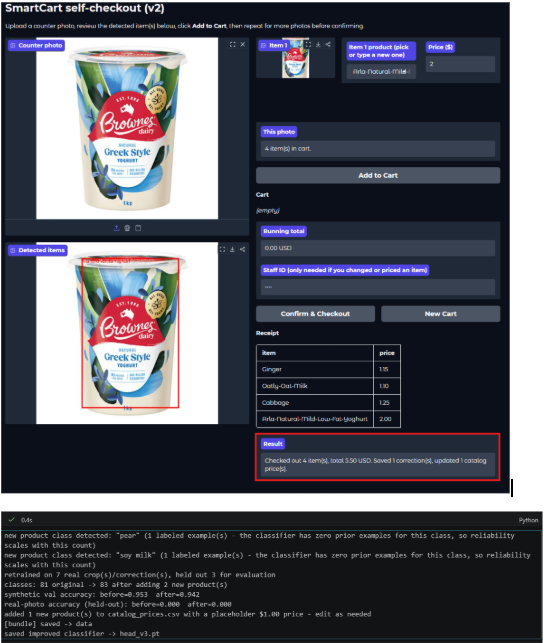

## As integrated into this capstone (what shipped where)

Huimin's editable-receipt loop above was verified on her standalone notebook (81-class course dataset, USD, `./data` bundle). It became the skeleton of the shipped final app (`day_5/Day5b_gradio_demo_v2.ipynb`), with her original preserved under `reference/huimin_originals/`:

- **Shipped as-is:** the multi-photo cart UI (per-item crop/dropdown/price slots, Add to Cart accumulation); staff-PIN-gated corrections and price edits (`resolve_checkout_changes`); `append_correction()` -> `corrections_manifest.csv`; dynamic class growth for never-seen products with placeholder catalog rows (now Day 3's "Retrain from checkout corrections" cell producing `head_v3`); newest-head auto-deploy in Day 5a (`head_v3` -> `head_v2` -> `head`); `persist_catalog_price`; the markdown-table workaround for the gr.Dataframe re-render bug; the `free_port()` launch helper; detector conf=0.25 (which fixed the multi-box-on-single-product issue).
- **Adapted:** repointed from `./data`/81-class/USD to the shared SG bundle — receipts are now SGD; the confidence gate her draft dropped was restored on top of her UI; the launch cell was made headless-safe.
- **Extended after integration:** 9% GST + plastic-bag question on her receipt flow; Basket mode + per-slot Include ticks on her slot UI.
- Her verified quote ("total 5.50 USD") is from the standalone run; the shipped app's equivalent smoke test verifies SGD receipts with GST and bag-charge math.

# D3 + Final app (v3) - Maxton Huang | Split boxes, in-app retrain, dynamic class growth

Merged as PR #1: `day_5/Day5b_gradio_demo_v3.ipynb` (a superset of the v2 app - v2 itself
untouched, byte-verified), one new Day 3 cell, and a full write-up in `docs/V3_CHANGELOG.md`.
Implements the instructor's feedback items end-to-end.

## 1. Split tool - fix boxes that contain two or more products

What: An "Item to split" picker opens a click canvas on the item's unresized crop: two
clicks define each sub-box (with an 8px sliver guard), or **Auto-split** proposes sub-boxes
via FastSAM (editable before applying). **Apply** classifies every sub-crop through the
normal confidence-gated path and splices the results into the item slots in place of the
merged item.

Why: A single red detector box often covers several products (the exact failure the team's
basket photo exposed); before this, the only remedies were re-photographing or manual entry.

Result: Merged detections can now be corrected at the counter in seconds, and each sub-item
flows through the ordinary correct/price/checkout path - including into the corrections
manifest for retraining.

## 2. In-app retrain - the self-improvement loop without leaving the app

What: A staff-PIN-gated **Retrain model** button folds `corrections_manifest.csv` into a new
head trained on Day 3's persisted feature pool (new Day 3 cell saves `base_feats.npy` +
train/val labels), augments single-example new classes with Day-4-style jitter, exports
`head_v3.onnx` behind a 1e-3 ONNX-parity gate, and hot-swaps the live session - `head.onnx`
is never written, and any failure (wrong PIN, no corrections, parity) leaves the live model
untouched.

Why: v2 saved corrections but needed a notebook re-run to learn from them; a cashier can't
re-run notebooks.

Result: Type a new product's name + price at checkout, confirm with the staff PIN, press
Retrain - the product is immediately in every dropdown, predictable by the classifier, and
priced. Verified with a live 25 -> 26-class rehearsal (parity 2.1e-06, baseline head
byte-identical).

## 3. Dynamic class growth done safely

What: Append-only class-list growth (existing logit indices never shift), before/after
validation accuracy compared by class NAME (immune to index shifts), a gallery-embedding
row appended per new class so Basket mode's open-set gate accepts the new product, and SGD
placeholder catalog rows that never clobber staff-set prices.

Why: Naive class growth (re-sorting the union) silently remaps every prediction; this keeps
both retrain paths (in-app and Day 3 offline) writing the same `head_v3` + `class_list_v3.json`
contract that Day 5a auto-deploys.

## As integrated into this capstone

Reviewed and re-verified on the team machine (2026-07-11): PR confirmed to touch nothing
else (v2 byte-identical, Day 3 gained exactly 2 cells); Day 3 re-run wrote the base-pool
artifacts; v3 executed end-to-end headless with all inherited v2 checks passing (GST/bag
math, Basket mode 7 slots on the team basket photo, auto-handoff). One reviewer fix after
merge: the committed launch cell had `LAUNCH = True` hardcoded from interactive testing -
restored the headless-safe `SC_LAUNCH_GRADIO` guard so scripted runs can't hijack port 7861.